# Histogram binning during image reconstruction
Binning in context of this notebook is combining several adjacent TCSPC bins into one wider bin Δt. It can be usefull if unnecessarily high temporal hardware resolution was used. In .ptu header this stored as *MeasDesc_Resolution* parameter.

Binning doesn't give you more photons or more fundamental information. It gives you a lower-dimensional representation in which each element has better counting statistics, at the cost of temporal resolution. You can expect

* almost no effect on mean lifetime,
* reduced visual/statistical noise per histogram bin,
* essentially no effect on phasor coordinates at sufficiently fine bins,
* progressively larger phasor attenuation once ωΔt becomes appreciable,
* progressively larger quantization error in the mean arrival time as Δt increases.



Read image acquired with mono-directional scan

In [1]:
from tttrkit.ptuio.reader import TTTRReader


reader = TTTRReader('../../data/MultiHarp150_2025-06-18_16-33-24.274_f1_ch1_accu1_px500.ptu')
for key, value in reader.header.tags.items():
    print(f'{key}: {value}')


TTResult_StopReason: 0
File_Comment: N/A
File_CreatingTime: 2025-06-18 16:33:24.274000
CreatorSW_Name: Imspector
Measurement_Mode: 3
Measurement_SubMode: 3
$StartedByRemoteInterface: False
CreatorSW_Version: 16.3.21879-w2448
File_GUID: {4F4E879F-16F7-4761-FE88-E1342625014E}
Fast_Load_End: <Empty>
CreatorSW_SVNBuild: 21879
HW_Type: MultiHarp 150 4P
HW_Version: 1.0
HW_PartNo: 930043
HW_SerialNo: 1050703
HW_Features: 183
ImgHdr_Frame: 3
ImgHdr_LineStart: 1
ImgHdr_LineStop: 2
MeasDesc_AcquisitionTime: 1665
ImgHdr_PixX: 500
ImgHdr_PixY: 500
ImgHdr_TimePerPixel: 0.005
UsrAI_usrTagVersion: 1.0.0
UsrAIScanAx_Label[0]: ExpControl X
ImgHdr_X0: -62.5
UsrAIScanAx_Label[1]: ExpControl Y
ImgHdr_Y0: -62.5
ImgHdr_PixResol: 0.25000000000000006
UsrAI_ScanAxes: 2
ImgHdr_BiDirect: False
ImgHdr_Dimensions: 3
ImgHdr_Ident: 13
HW_BaseResolution: 5e-12
MeasDesc_GlobalResolution: 2.5000075000225e-08
MeasDesc_Resolution: 5e-12
MeasDesc_BinningFactor: 1
MeasDesc_Offset: 0
MeasDesc_Restart: False
MeasDesc_Invalid

Here the image data is saved in the header, but accumulations and sequence configuration is not. So it must be known or guessed...

In [2]:

Measurement_SubMode = reader.header.tags.get("Measurement_SubMode")

if Measurement_SubMode<1: 
    print("Not an image. You must set scanning configuration.")
else:
    ImgHdr_PixX = reader.header.tags.get("ImgHdr_PixX")
    ImgHdr_PixY = reader.header.tags.get("ImgHdr_PixY")
    print("Number of pixels from header: ", ImgHdr_PixX)
    print("Number of lines from the header: ", ImgHdr_PixY)
    # Number of lines is only correct for 1 sequence + 1 accumulation


Number of pixels from header:  500
Number of lines from the header:  500


Define scanning configuration

In [3]:
from tttrkit.ptuio.utils import estimate_tcspc_bins
from tttrkit.ptuio.decoder import T3OverflowCorrector
from tttrkit.ptuio.reconstructor import ScanConfig, ImageReconstructor

import numpy as np

bin_factor = 8


cfg = ScanConfig(
    bidirectional=False, 
    frames= 1,
    lines=500, 
    pixels=500, 
    line_accumulations= (1,),
    max_detector=1,
    )

wrap = reader.header.tags.get("TTResultFormat_WrapAround", 1024)  # default fallback
repetition_rate = reader.header.tags.get("TTResult_SyncRate",40e6)  
tcspc_resolution = reader.header.tags.get("MeasDesc_Resolution",5e-12)
tcspc_bins = estimate_tcspc_bins(reader.header.tags,buffer=100) # for high resolution (<10ps), tcspcs channel overflow can be expected -> set higher buffer

corrector = T3OverflowCorrector(wraparound=wrap)


In [4]:
import ctypes
from ctypes import wintypes
import gc
import time


class PROCESS_MEMORY_COUNTERS_EX(ctypes.Structure):
    _fields_ = [
        ("cb", wintypes.DWORD),
        ("PageFaultCount", wintypes.DWORD),
        ("PeakWorkingSetSize", ctypes.c_size_t),
        ("WorkingSetSize", ctypes.c_size_t),
        ("QuotaPeakPagedPoolUsage", ctypes.c_size_t),
        ("QuotaPagedPoolUsage", ctypes.c_size_t),
        ("QuotaPeakNonPagedPoolUsage", ctypes.c_size_t),
        ("QuotaNonPagedPoolUsage", ctypes.c_size_t),
        ("PagefileUsage", ctypes.c_size_t),
        ("PeakPagefileUsage", ctypes.c_size_t),
        ("PrivateUsage", ctypes.c_size_t),
    ]


psapi = ctypes.WinDLL("psapi", use_last_error=True)
psapi.GetProcessMemoryInfo.argtypes = [
    wintypes.HANDLE,
    ctypes.POINTER(PROCESS_MEMORY_COUNTERS_EX),
    wintypes.DWORD,
]
psapi.GetProcessMemoryInfo.restype = wintypes.BOOL
kernel32 = ctypes.WinDLL("kernel32", use_last_error=True)
kernel32.GetCurrentProcess.restype = wintypes.HANDLE


def working_set_mb():
    counters = PROCESS_MEMORY_COUNTERS_EX()
    counters.cb = ctypes.sizeof(counters)
    if not psapi.GetProcessMemoryInfo(
        kernel32.GetCurrentProcess(),
        ctypes.byref(counters),
        counters.cb,
    ):
        raise ctypes.WinError(ctypes.get_last_error())
    return counters.WorkingSetSize / 1024**2


def dataset_size_mb(dataset):
    return sum(data_array.nbytes for data_array in dataset.data_vars.values()) / 1024**2


def benchmark_reconstruction(bin_factor):
    gc.collect()
    memory_before_mb = working_set_mb()
    peak_memory_mb = memory_before_mb
    benchmark_reader = TTTRReader(reader.path)
    benchmark_corrector = T3OverflowCorrector(wraparound=wrap)
    benchmark_reconstructor = ImageReconstructor(
        config=cfg,
        laser_sync_rate=repetition_rate,
        tcspc_channels=tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        tcspc_bin_factor=bin_factor,
        outputs=None,
    )

    start = time.perf_counter()
    for chunk in benchmark_reader.iter_chunks():
        benchmark_reconstructor.update(benchmark_corrector.correct(chunk))
        peak_memory_mb = max(peak_memory_mb, working_set_mb())
    benchmark_result = benchmark_reconstructor.finalize()
    elapsed_s = time.perf_counter() - start
    memory_after_mb = working_set_mb()

    return benchmark_result, {
        "bin factor": bin_factor,
        "time (s)": elapsed_s,
        "working-set increase (MB)": memory_after_mb - memory_before_mb,
        "peak working-set increase (MB)": peak_memory_mb - memory_before_mb,
        "result size (MB)": dataset_size_mb(benchmark_result),
        "histogram bins": benchmark_reconstructor.tcspc_hist_channels,
    }


result, no_binning_metrics = benchmark_reconstruction(bin_factor=1)
result_binned, binned_metrics = benchmark_reconstruction(bin_factor=bin_factor)

for metrics in (no_binning_metrics, binned_metrics):
    print(
        f"{metrics['bin factor']}x binning: "
        f"{metrics['time (s)']:.3f} s, "
        f"working-set increase {metrics['working-set increase (MB)']:.1f} MB, "
        f"peak increase {metrics['peak working-set increase (MB)']:.1f} MB, "
        f"result size {metrics['result size (MB)']:.1f} MB, "
        f"{metrics['histogram bins']} histogram bins"
    )

print(
    f"Time ratio (binned / unbinned): "
    f"{binned_metrics['time (s)'] / no_binning_metrics['time (s)']:.2f}x"
)

Reconstruction finished.
Reconstruction finished.
1x binning: 0.746 s, working-set increase 10.8 MB, peak increase 8.9 MB, result size 3.9 MB, 5101 histogram bins
8x binning: 0.714 s, working-set increase 12.3 MB, peak increase 9.0 MB, result size 3.8 MB, 638 histogram bins
Time ratio (binned / unbinned): 0.96x


Now reconstruct with 8x binning

In [5]:


reconstructor = ImageReconstructor(
        config=cfg, 
        laser_sync_rate=repetition_rate, 
        tcspc_channels= tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        outputs=None # this will read everything
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result = reconstructor.finalize()




reconstructor = ImageReconstructor(
        config=cfg, 
        laser_sync_rate=repetition_rate, 
        tcspc_channels= tcspc_bins,
        tcspc_resolution=tcspc_resolution,
        tcspc_bin_factor=bin_factor,
        outputs=None, # this will read everything
        )

for chunk in reader.iter_chunks():
    corrected_chunk = corrector.correct(chunk)
    reconstructor.update(corrected_chunk)

result_binned = reconstructor.finalize()

Reconstruction finished.
Reconstruction finished.


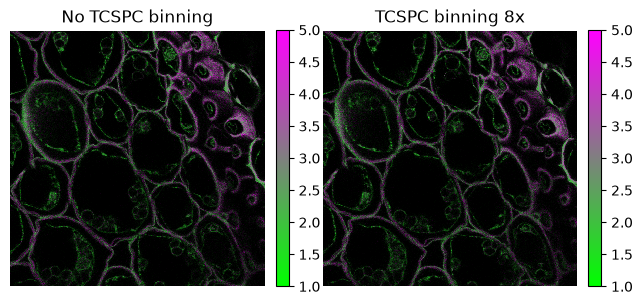

In [6]:
from tttrkit.analysis.visualization import create_FLIM_image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
colormap = mcolors.LinearSegmentedColormap.from_list("green_red", ["lime", "magenta"])
# colormap = mcolors.

lt_min = 1 
lt_max = 5

FLIM_image = create_FLIM_image(mean_photon_arrival_time=result.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * result.tcspc_resolution.values * 1e9, 
                               intensity=result.photon_count.isel(frame=0,sequence=0,channel=0).values, 
                               lt_min = lt_min, 
                               lt_max = lt_max,
                               int_min=0,
                               int_max=50,
                               colormap=colormap,
                               )

FLIM_image_binned = create_FLIM_image(mean_photon_arrival_time=result_binned.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values * result_binned.tcspc_resolution.values * 1e9, 
                               intensity=result_binned.photon_count.isel(frame=0,sequence=0,channel=0).values, 
                               lt_min = lt_min, 
                               lt_max = lt_max,
                               int_min=0,
                               int_max=50,
                               colormap=colormap
                               )

fig, ax = plt.subplots(1,2)
img = ax[0].imshow(FLIM_image, cmap = colormap,vmin=lt_min, vmax=lt_max, interpolation='nearest')
ax[0].set_title('No TCSPC binning')
ax[0].axis("off")
ax[1].imshow(FLIM_image_binned, cmap = colormap,vmin=lt_min, vmax=lt_max, interpolation='nearest')
ax[1].set_title(f'TCSPC binning {bin_factor}x')
ax[1].axis("off")


fig.colorbar(img, ax=ax[0], fraction=0.046, pad=0.04)
fig.colorbar(img, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

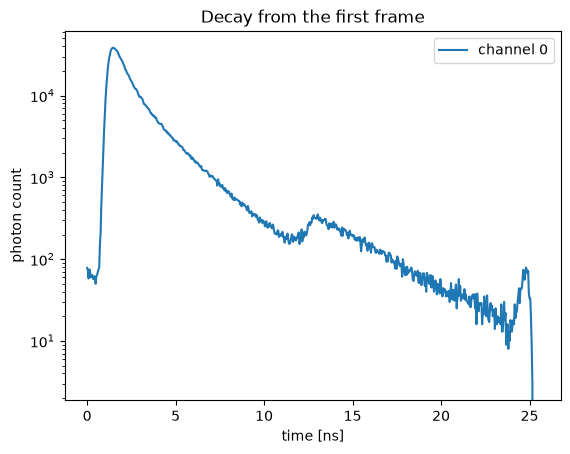

In [7]:
dtimes = result_binned.tcspc_channel.values * result_binned.tcspc_histogram_resolution.values * 1e9
fig, ax = plt.subplots()
ax.semilogy(dtimes,result_binned.tcspc_histogram.isel(frame=0,channel=0).values)
# ax.semilogy(dtimes,result.tcspc_histogram.isel(frame=0,channel=1).values)
ax.set_xlabel('time [ns]')
ax.set_ylabel('photon count')
ax.legend({
    'channel 0',
    })
plt.title("Decay from the first frame")
plt.show()

Histogram of lifetimes

In [8]:
mat = result.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values.ravel() * 1e9 * result.tcspc_resolution.values
mat_binned = result_binned.mean_arrival_time.isel(frame=0,sequence=0,channel=0).values.ravel() * 1e9 * result_binned.tcspc_resolution.values


mean_arrival_time_hist, bins = np.histogram(
    mat,
    bins=200,
    range=(.1,10),
)



mean_arrival_time_binned_hist, bins_binned = np.histogram(
    mat_binned,
    bins=200,
    range=(.1,10),
)

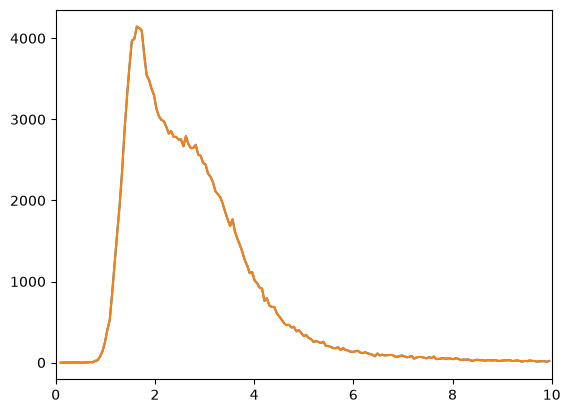

In [9]:
_,ax = plt.subplots()

ax.plot(bins[:-1],mean_arrival_time_hist)
ax.plot(bins_binned[:-1],mean_arrival_time_binned_hist)
ax.set_xlim(0,10)

plt.show()

In [10]:
g = result.phasor_g.transpose("frame","sequence","channel","line","pixel")
s = result.phasor_s.transpose("frame","sequence","channel","line","pixel")
g = g.isel(frame=0,sequence=0,channel=0)
s = s.isel(frame=0,sequence=0,channel=0)

# Convert to numpy
g = np.array(g,dtype=float)
s = np.array(s,dtype=float)
phasor = (g + 1j * s).astype(complex)


In [11]:
g_binned = result_binned.phasor_g.transpose("frame","sequence","channel","line","pixel")
s_binned = result_binned.phasor_s.transpose("frame","sequence","channel","line","pixel")
g_binned = g_binned.isel(frame=0,sequence=0,channel=0)
s_binned = s_binned.isel(frame=0,sequence=0,channel=0)

# Convert to numpy
g_binned = np.array(g_binned,dtype=float)
s_binned = np.array(s_binned,dtype=float)
phasor_binned = (g_binned + 1j * s_binned).astype(complex)


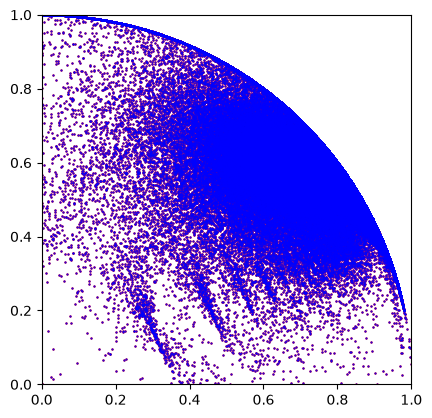

In [14]:
_,ax = plt.subplots()
ax.plot(g,s,'r.',markersize = 1.5)
ax.plot(g_binned,s_binned,'b.',markersize=1)
ax.set_aspect('equal')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.show()
